In [ ]:
import time
import random
import pandas as pd

# ==========================================
# 1. 힙 정렬 (클래스 기반)
# ==========================================
class MaxHeap:
    def __init__(self, arr):
        self.heap = list(arr)
        self.comparisons = 0
        self.moves = 0

    def _heapify(self, n, i):
        largest = i
        left = 2 * i + 1
        right = 2 * i + 2

        if left < n:
            self.comparisons += 1
            if self.heap[left] > self.heap[largest]:
                largest = left

        if right < n:
            self.comparisons += 1
            if self.heap[right] > self.heap[largest]:
                largest = right

        if largest != i:
            self.heap[i], self.heap[largest] = self.heap[largest], self.heap[i]
            self.moves += 3
            self._heapify(n, largest)

    def sort(self):
        n = len(self.heap)
        start_time = time.perf_counter()

        for i in range(n // 2 - 1, -1, -1):
            self._heapify(n, i)

        for i in range(n - 1, 0, -1):
            self.heap[0], self.heap[i] = self.heap[i], self.heap[0]
            self.moves += 3
            self._heapify(i, 0)

        elapsed = time.perf_counter() - start_time
        return self.comparisons, self.moves, elapsed


# ==========================================
# 2. 병합 정렬
# ==========================================
def merge(a, lo, mid, hi, temp, metrics):
    i, j, k = lo, mid + 1, lo
    while i <= mid and j <= hi:
        metrics['comparisons'] += 1
        if a[i] <= a[j]:
            temp[k] = a[i]
            i += 1
        else:
            temp[k] = a[j]
            j += 1
        metrics['moves'] += 1
        k += 1

    while i <= mid:
        temp[k] = a[i]
        i += 1; k += 1
        metrics['moves'] += 1

    while j <= hi:
        temp[k] = a[j]
        j += 1; k += 1
        metrics['moves'] += 1

    for idx in range(lo, hi + 1):
        a[idx] = temp[idx]
        metrics['moves'] += 1

def merge_sort_helper(a, lo, hi, temp, metrics):
    if lo >= hi:
        return
    mid = (lo + hi) // 2
    merge_sort_helper(a, lo, mid, temp, metrics)
    merge_sort_helper(a, mid + 1, hi, temp, metrics)
    merge(a, lo, mid, hi, temp, metrics)

def merge_sort(arr):
    a = list(arr)
    n = len(a)
    temp = [0] * n
    metrics = {'comparisons': 0, 'moves': 0}

    start_time = time.perf_counter()
    merge_sort_helper(a, 0, n - 1, temp, metrics)
    elapsed = time.perf_counter() - start_time

    return metrics['comparisons'], metrics['moves'], elapsed


# ==========================================
# 3. 셸 정렬 (기본 - 절반 축소)
# ==========================================
def shell_sort(arr):
    a = list(arr)
    n = len(a)
    comparisons = 0
    moves = 0

    start_time = time.perf_counter()
    gap = n // 2
    while gap >= 1:
        for i in range(gap, n):
            key = a[i]
            moves += 1
            j = i - gap
            while j >= 0:
                comparisons += 1
                if a[j] > key:
                    a[j + gap] = a[j]
                    moves += 1
                    j -= gap
                else:
                    break
            a[j + gap] = key
            moves += 1
        gap //= 2

    elapsed = time.perf_counter() - start_time
    return comparisons, moves, elapsed


# ==========================================
# 4. 셸 정렬 (크누스 수열)
# ==========================================
def shell_sort_knuth(arr):
    a = list(arr)
    n = len(a)
    comparisons = 0
    moves = 0

    start_time = time.perf_counter()
    gap = 1
    while gap < n // 3:
        gap = 3 * gap + 1

    while gap >= 1:
        for i in range(gap, n):
            key = a[i]
            moves += 1
            j = i - gap
            while j >= 0:
                comparisons += 1
                if a[j] > key:
                    a[j + gap] = a[j]
                    moves += 1
                    j -= gap
                else:
                    break
            a[j + gap] = key
            moves += 1
        gap = (gap - 1) // 3

    elapsed = time.perf_counter() - start_time
    return comparisons, moves, elapsed




=================== [ Sorting Benchmark Results ] ===================

                                   Comparisons   Moves  Time (ms)
Dataset        Algorithm                                         
Random (8000)  Heap Sort (Class)        182717  289680   120.4993
               Merge Sort                93571  207616   110.5129
               Shell Sort (Half)        212337  304363   106.9404
               Shell Sort (Knuth)       181655  244263    80.5321
Random (500)   Heap Sort (Class)          7393   12033     3.8187
               Merge Sort                 3865    8976     4.2156
               Shell Sort (Half)          6878   10675     2.6200
               Shell Sort (Knuth)         5766    8441     2.3488
Sorted (500)   Heap Sort (Class)          7756   13062     4.2029
               Merge Sort                 2272    8976     3.6866
               Shell Sort (Half)          3506    7012     1.3684
               Shell Sort (Knuth)         2457    4914     1.0939
Rever

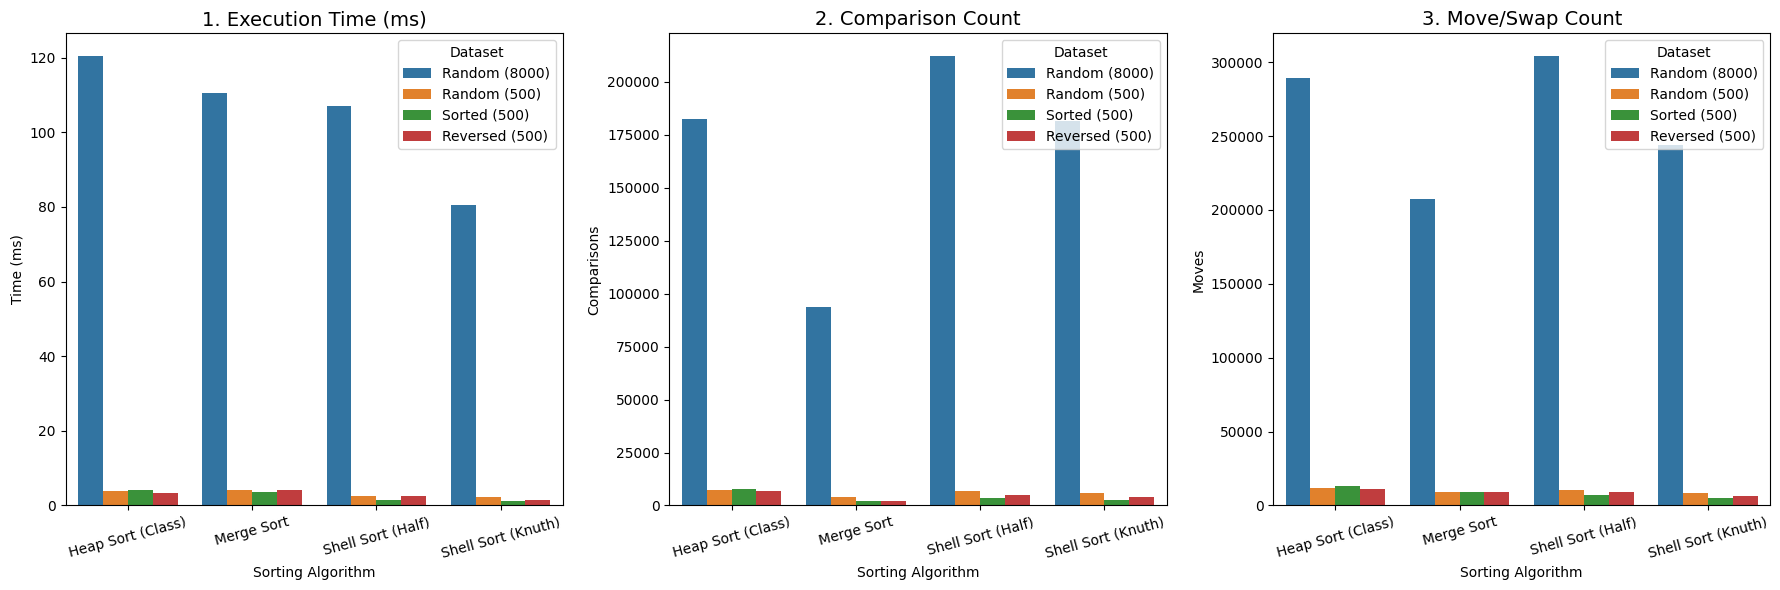

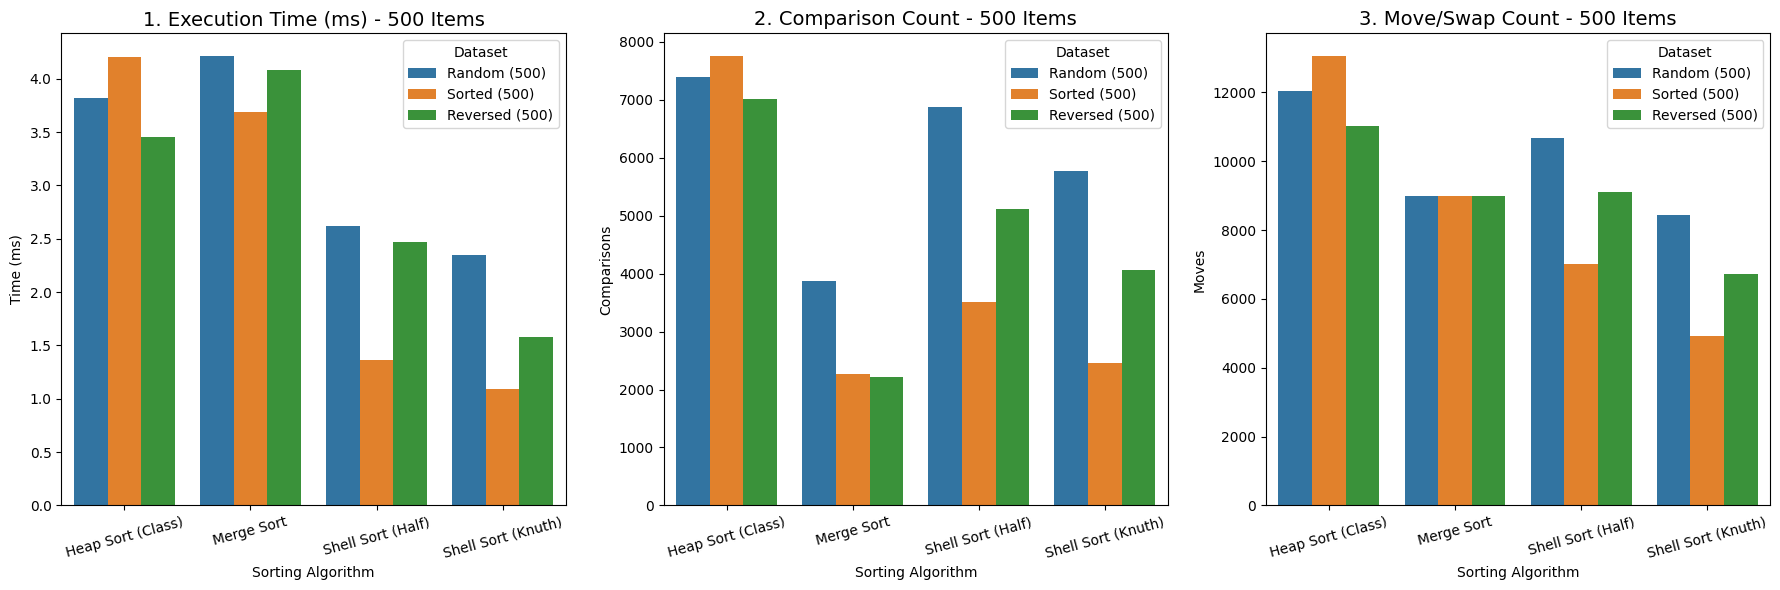

In [ ]:
# ==========================================
# 테스트 및 시각화
# ==========================================
if __name__ == "__main__":
    random.seed(42)

    datasets = {
        "Random (8000)": [random.randint(1, 100000) for _ in range(8000)],
        "Random (500)": [random.randint(1, 10000) for _ in range(500)],
        "Sorted (500)": list(range(1, 501)),
        "Reversed (500)": list(range(500, 0, -1))
    }

    algorithms = {
        "Heap Sort (Class)": lambda arr: MaxHeap(arr).sort(),
        "Merge Sort": merge_sort,
        "Shell Sort (Half)": shell_sort,
        "Shell Sort (Knuth)": shell_sort_knuth
    }

    results = []
    for data_name, data in datasets.items():
        for algo_name, algo_func in algorithms.items():
            comp, moves, elapsed = algo_func(data)
            results.append({
                "Dataset": data_name,
                "Algorithm": algo_name,
                "Comparisons": comp,
                "Moves": moves,
                "Time (ms)": round(elapsed * 1000, 4)
            })

    df = pd.DataFrame(results)

    df_styled = df.set_index(["Dataset", "Algorithm"])
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', 1000)
    print("=================== [ Sorting Benchmark Results ] ===================\n")
    print(df_styled.to_string())
    print("\n=====================================================================")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    sns.barplot(data=df, x='Algorithm', y='Time (ms)', hue='Dataset', ax=axes[0])
    axes[0].set_title('1. Execution Time (ms)', fontsize=14)
    axes[0].set_xlabel('Sorting Algorithm')
    axes[0].set_ylabel('Time (ms)')
    axes[0].tick_params(axis='x', rotation=15)

    sns.barplot(data=df, x='Algorithm', y='Comparisons', hue='Dataset', ax=axes[1])
    axes[1].set_title('2. Comparison Count', fontsize=14)
    axes[1].set_xlabel('Sorting Algorithm')
    axes[1].set_ylabel('Comparisons')
    axes[1].tick_params(axis='x', rotation=15)

    sns.barplot(data=df, x='Algorithm', y='Moves', hue='Dataset', ax=axes[2])
    axes[2].set_title('3. Move/Swap Count', fontsize=14)
    axes[2].set_xlabel('Sorting Algorithm')
    axes[2].set_ylabel('Moves')
    axes[2].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

# ==========================================
# 8000개 데이터 제거버전
# ==========================================
df_small = df[df['Dataset'] != "Random (8000)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=df_small, x='Algorithm', y='Time (ms)', hue='Dataset', ax=axes[0])
axes[0].set_title('1. Execution Time (ms) - 500 Items', fontsize=14)
axes[0].set_xlabel('Sorting Algorithm')
axes[0].set_ylabel('Time (ms)')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=df_small, x='Algorithm', y='Comparisons', hue='Dataset', ax=axes[1])
axes[1].set_title('2. Comparison Count - 500 Items', fontsize=14)
axes[1].set_xlabel('Sorting Algorithm')
axes[1].set_ylabel('Comparisons')
axes[1].tick_params(axis='x', rotation=15)

sns.barplot(data=df_small, x='Algorithm', y='Moves', hue='Dataset', ax=axes[2])
axes[2].set_title('3. Move/Swap Count - 500 Items', fontsize=14)
axes[2].set_xlabel('Sorting Algorithm')
axes[2].set_ylabel('Moves')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()